# Arctic Disser Pipeline

Чтобы сменить территорию/сервис/параметры — отредактируй [pipeline/config.py](pipeline/config.py).

## Setup

In [1]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, '.')


## 1. Базовый расчёт

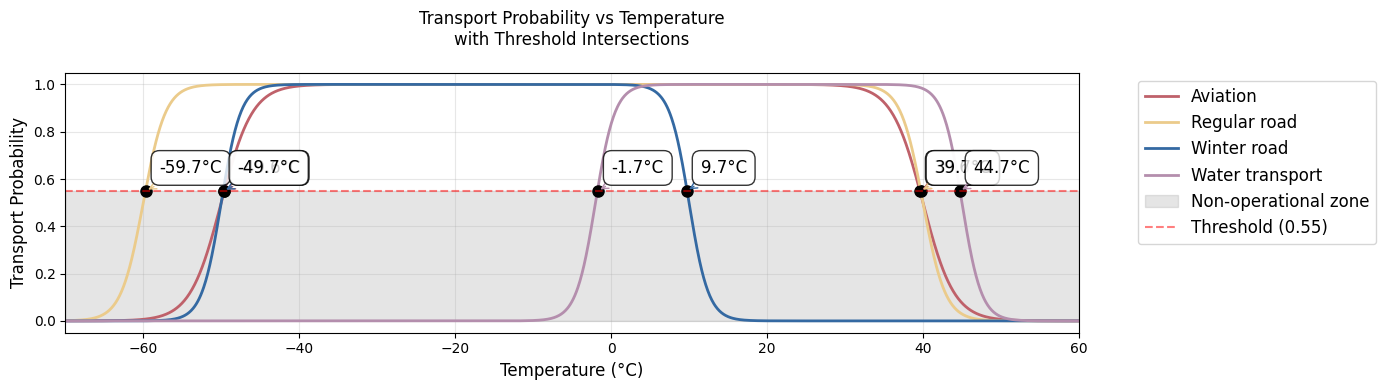

========== yanao_kras ==========


Running network analysis: 100%|██████████| 12/12 [00:01<00:00, 10.10it/s]


In [2]:
from pipeline import run_base

all_results, ctx = run_base.run()
settl_name = ctx["settl_name"]
service_name = ctx["service_name"]


## 2. Визуализации

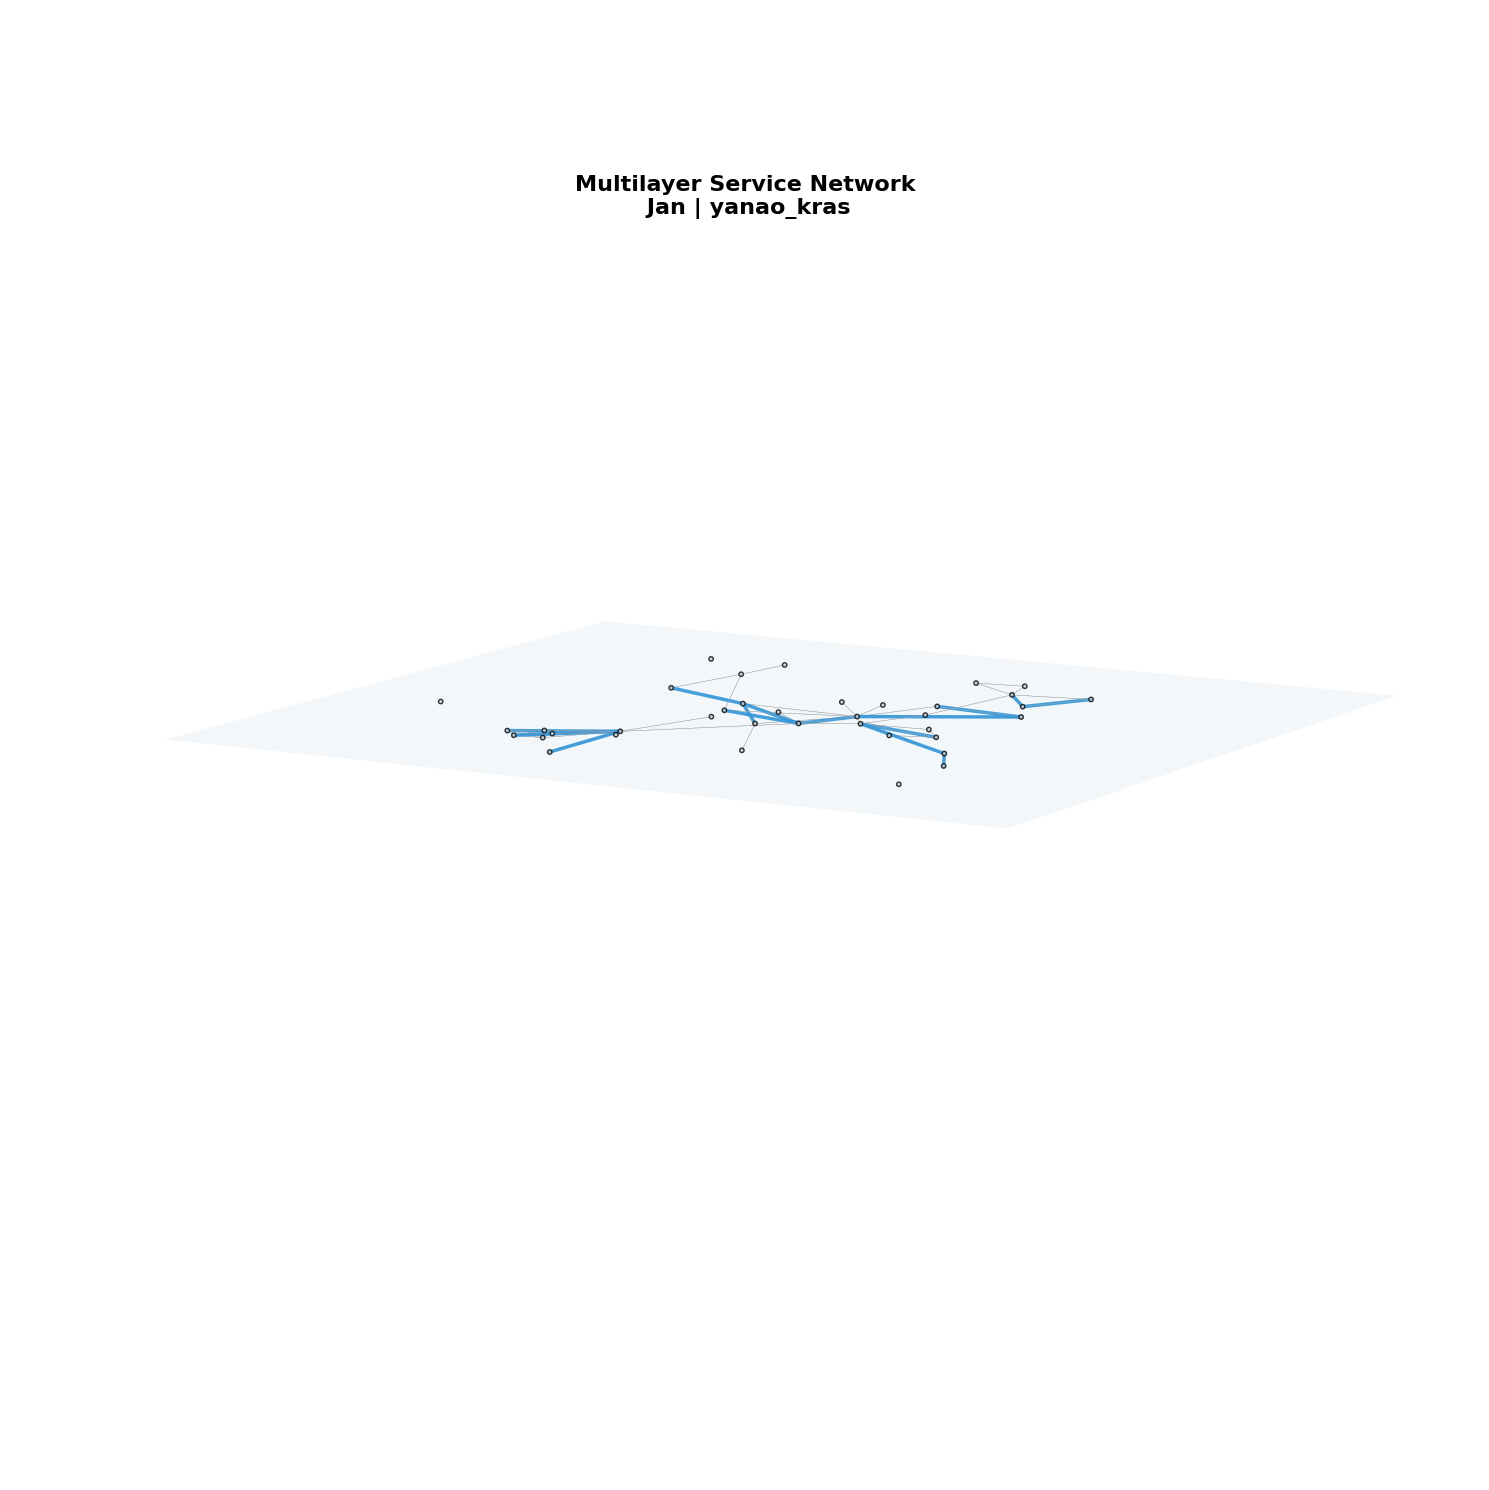

In [3]:
from pipeline import run_plots

_ = run_plots.multilayer(all_results, settl_name)


In [4]:
_ = run_plots.sankey(all_results, settl_name)


Creating Sankey for 10 time periods...
Excluding 16 self-sufficient settlements: ['Dikson', 'Nahodka', 'Zhdaniha', 'Novyj Urengoj', 'Popigaj', 'Volochanka', "Ust'-Avam", 'Ratta', "Noril'sk", 'Tarko-Sale', 'Gaz-Sale', 'Heta', 'Gyda', 'Vorontsovo', 'Novaja', 'Karaul']
Found 22 consumers
T1: 15 assignments, 7 no provider
T2: 15 assignments, 7 no provider
T3: 15 assignments, 7 no provider
T4: 15 assignments, 7 no provider
T5: 15 assignments, 7 no provider
T6: 10 assignments, 12 no provider
T7: 10 assignments, 12 no provider
T8: 10 assignments, 12 no provider
T9: 10 assignments, 12 no provider
T10: 15 assignments, 7 no provider
Created 122 nodes
Created 220 flows


In [5]:
run_plots.circular(all_results, settl_name)


[Figure({
     'data': [{'fill': 'toself',
               'fillcolor': '#1E88E5',
               'hovertemplate': "<b>Dudinka</b><br>Demand: 2318.0<br>Provider: Noril'sk<extra></extra>",
               'legendgroup': 'consumers',
               'mode': 'none',
               'name': 'Consumers',
               'showlegend': True,
               'type': 'scatter',
               'x': [0.9607612597048361, 0.9393386869454726, 0.9134409435814912,
                     0.8831914109038358, 0.8487342028740875, 0.8102334795408371,
                     0.767872664953058, 0.7218535732964814, 0.6723954474162009,
                     0.619733914306159, 0.564119862541736, 0.5058182470035518,
                     0.4451068265869693, 0.382274840911083, 0.3176216323315665,
                     0.2514552198223553, 0.18409083152042344, 0.11584940292487868,
                     0.047056047905205685, -0.021961490196971474,
                     -0.019765341177274326, 0.04235044311468512,
                   

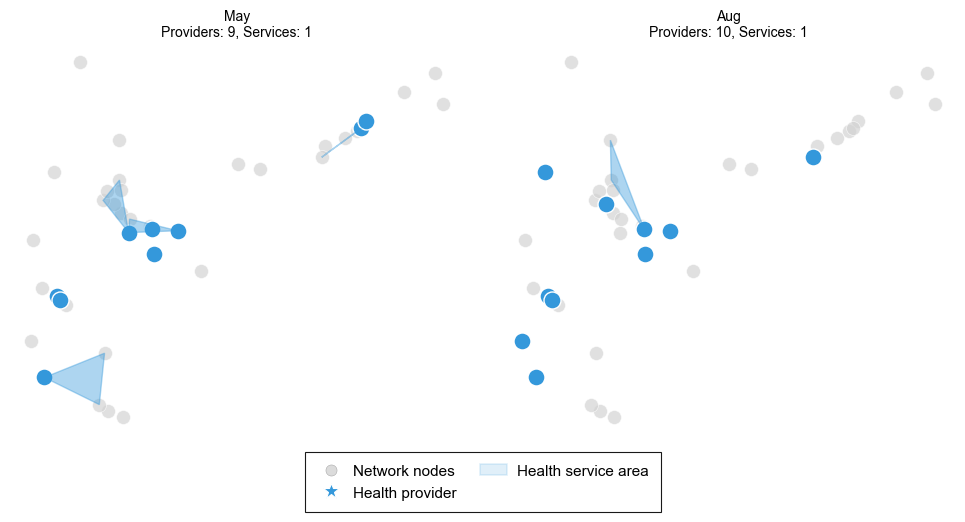

In [6]:
_ = run_plots.coverage(all_results, settl_name)


## 3. Солвер FLP — размещение новых объектов

In [7]:
from pipeline import run_solver

solver_result = run_solver.run(all_results)


Всего узлов: 38
Не обеспечены (provision < 1): 7


100%|██████████| 38/38 [00:00<00:00, 830.76it/s]


Рёбер в графе кандидатов: 43


100%|██████████| 20/20 [00:53<00:00,  2.70s/it]

Вместимости новых объектов: [50.0, 50.0, 50.0, 50.0, 67.0, 50.0, 60.0]
Привязка: {'Kazantsevo': ['Kazantsevo'], 'Karaul': ['Bajkalovsk', 'Dudinka', 'Karaul', 'Nosok', 'Tuhard', "Ust'-Port", 'Hantajskoe Ozero', 'Polikarpovsk', 'Potapovo'], 'Munguj': ['Munguj'], 'Levinskie Peski': ['Levinskie Peski'], 'Novorybnaja': ['Novorybnaja'], "Tol'ka": ["Krasnosel'kup", 'Tarko-Sale', 'Kikkiakki', 'Novyj Urengoj', "Tol'ka"], 'Syndassko': ['Syndassko']}


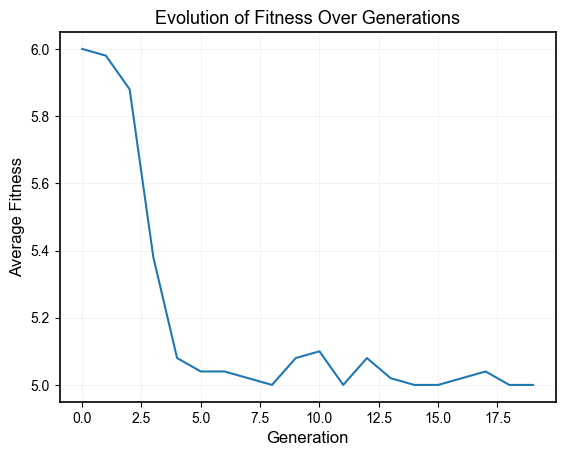

In [8]:
from method import fitness_plot, connect_blocks_plot

fitness_plot(solver_result["fitness_history"])


## 4. Улучшение сервисов (новые объекты из FLP)

In [9]:
# from pipeline import run_connectivity

# all_results, svc_ctx = run_connectivity.apply_services(all_results, solver_result, ctx)
# svc_ctx["df_compare"][svc_ctx["df_compare"]["delta"] != 0]


## 5. Улучшение связности (оптимизированные времена)

In [10]:
# all_results, conn_ctx = run_connectivity.apply_connectivity(
#     all_results, solver_result, ctx
# )
# conn_ctx["df_compare"][conn_ctx["df_compare"]["delta"] != 0]


## 5.5 Оба улучшения вместе

In [11]:
from pipeline import run_connectivity

all_results, both_ctx = run_connectivity.apply_both(all_results, solver_result, ctx)
both_ctx["df_compare"][both_ctx["df_compare"]["delta"] != 0]


  Kazantsevo: +50 capacity
  Karaul: +50 capacity
  Munguj: +50 capacity
  Levinskie Peski: +50 capacity
  Novorybnaja: +67 capacity
  Tol'ka: +50 capacity
  Syndassko: +60 capacity


Running network analysis: 100%|██████████| 12/12 [00:00<00:00, 14.73it/s]

Пересчёт с обоими улучшениями завершён → ключ 'health_both'


,provision_before,provision_after,delta
name,,,
Syndassko,0.0,1.0,1.0
Kikkiakki,0.0,1.0,1.0
Levinskie Peski,0.0,1.0,1.0
Novorybnaja,0.0,1.0,1.0
Munguj,0.0,1.0,1.0
Kazantsevo,0.0,1.0,1.0
Polikarpovsk,0.0,1.0,1.0


## 6. Визуализации после улучшений

In [12]:
both_ctx


{'net': <scripts.calculator.calculator_stat.AgglomerationNetwork at 0x122455150>,
 'G': <networkx.classes.multigraph.MultiGraph at 0x122310290>,
 'df_compare':                   provision_before  provision_after  delta
 name                                                      
 Syndassko                      0.0              1.0    1.0
 Kikkiakki                      0.0              1.0    1.0
 Levinskie Peski                0.0              1.0    1.0
 Novorybnaja                    0.0              1.0    1.0
 Munguj                         0.0              1.0    1.0
 Kazantsevo                     0.0              1.0    1.0
 Polikarpovsk                   0.0              1.0    1.0
 Tazovskij                      1.0              1.0    0.0
 Novyj Urengoj                  1.0              1.0    0.0
 Tol'ka                         1.0              1.0    0.0
 Heta                           1.0              1.0    0.0
 Hatanga                        1.0              1.0    0.0
 

In [13]:
all_results[settl_name].keys()


dict_keys(['health', 'health_both'])

In [14]:
all_results[settl_name]["health_both"].keys()


dict_keys(['net', 'stats', 'graphs', 'records', 'results', 'G_undirected'])


==================== health_both ====================
Creating Sankey for 10 time periods...
Excluding 16 self-sufficient settlements: ['Zhdaniha', 'Novyj Urengoj', 'Munguj', 'Volochanka', "Ust'-Avam", 'Ratta', 'Katyryk', 'Novorybnaja', 'Kazantsevo', "Noril'sk", 'Syndassko', 'Tarko-Sale', 'Gaz-Sale', 'Heta', 'Gyda', 'Levinskie Peski']
Found 22 consumers
T1: 22 assignments, 0 no provider
T2: 22 assignments, 0 no provider
T3: 22 assignments, 0 no provider
T4: 22 assignments, 0 no provider
T5: 22 assignments, 0 no provider
T6: 22 assignments, 0 no provider
T7: 22 assignments, 0 no provider
T8: 22 assignments, 0 no provider
T9: 22 assignments, 0 no provider
T10: 22 assignments, 0 no provider
Created 172 nodes
Created 220 flows


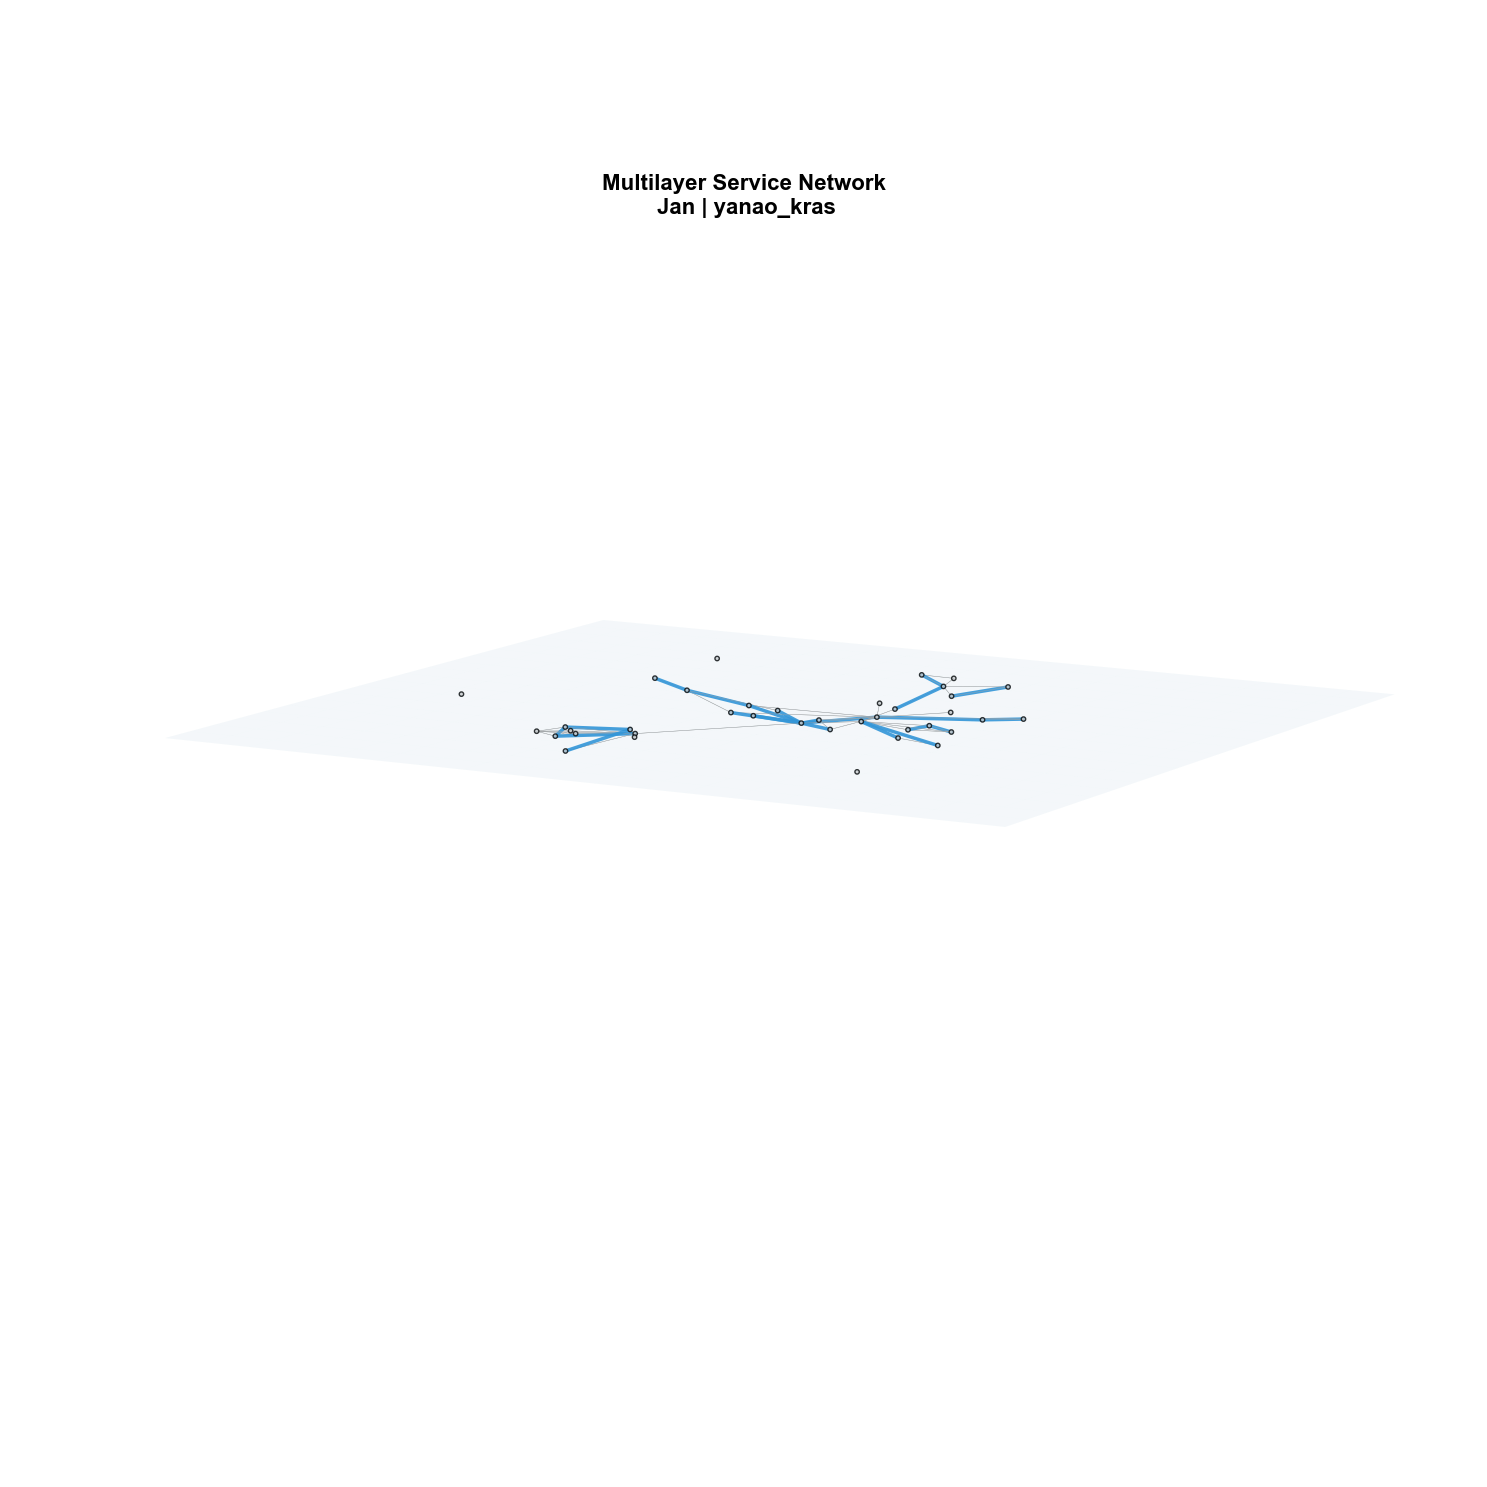

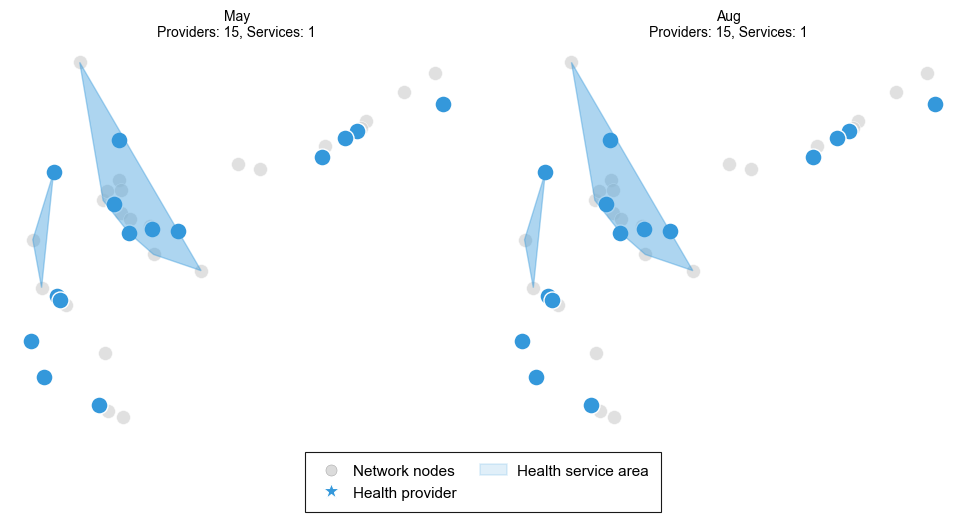

In [15]:
for SCENARIO in ["both"]:
    print(f"\n" + "=" * 20 + f" {service_name}_{SCENARIO} " + "=" * 20)
    all_results[settl_name][service_name] = all_results[settl_name][
        f"{service_name}_{SCENARIO}"
    ]
    run_plots.all_plots(all_results, settl_name)
